Loading Data

In [1]:
import torch

data = torch.load('data/eeg_14_70_std.pth', map_location='cpu')
print(type(data))
print(data.keys())

print(f"Number of samples: {len(data['dataset'])}")
print(f"Labels list (40 classes): {data['labels']}")

for i, sample in enumerate(data['dataset'][:8]):
    print(f"\nSample {i}:")
    print(f"  Label: {sample['label']}")
    print(f"  Subject: {sample['subject']}")
    print(f"  EEG shape: {sample['eeg'].shape} (channels x timepoints)")
    print(f"  Image index: {sample['image']}")

<class 'dict'>
dict_keys(['dataset', 'labels', 'images'])
Number of samples: 11965
Labels list (40 classes): ['n02389026', 'n03888257', 'n03584829', 'n02607072', 'n03297495', 'n03063599', 'n03792782', 'n04086273', 'n02510455', 'n11939491', 'n02951358', 'n02281787', 'n02106662', 'n04120489', 'n03590841', 'n02992529', 'n03445777', 'n03180011', 'n02906734', 'n07873807', 'n03773504', 'n02492035', 'n03982430', 'n03709823', 'n03100240', 'n03376595', 'n03877472', 'n03775071', 'n03272010', 'n04069434', 'n03452741', 'n03792972', 'n07753592', 'n13054560', 'n03197337', 'n02504458', 'n02690373', 'n03272562', 'n04044716', 'n02124075']

Sample 0:
  Label: 10
  Subject: 4
  EEG shape: torch.Size([128, 500]) (channels x timepoints)
  Image index: 0

Sample 1:
  Label: 30
  Subject: 4
  EEG shape: torch.Size([128, 511]) (channels x timepoints)
  Image index: 1

Sample 2:
  Label: 29
  Subject: 4
  EEG shape: torch.Size([128, 532]) (channels x timepoints)
  Image index: 2

Sample 3:
  Label: 10
  Subjec

In [9]:
import torch
import torch.nn as nn
import numpy as np
import collections
import matplotlib.pyplot as plt
from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader

Filter to Golfballs vs Eygptian cats



In [2]:
golf_label = 16
cat_label  = 39

filtered = [x for x in data['dataset'] if x['label'] in [golf_label, cat_label]]
for x in filtered:
    x['binary_label'] = 0 if x['label'] == golf_label else 1

print(f"Total samples: {len(filtered)}")

Total samples: 600


In [3]:
lengths = [x['eeg'].shape[1] for x in filtered]
print(set(lengths))
print(min(lengths))

{512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 538, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 765, 559, 561, 563, 566, 751, 581, 727, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 507, 508, 509, 510, 511}
492


Select Occipital Channels

In [5]:
import numpy as np
import collections

print(data.keys())
print(data['stddev'] if 'stddev' in data else "no stddev")
print(filtered[0].keys())

labels_counter = [x['label'] for x in filtered]
print(collections.Counter(labels_counter))
binary = [x['binary_label'] for x in filtered]
print(collections.Counter(binary))

print(data['labels'])

min_len = min([x['eeg'].shape[1] for x in filtered])
occipital_channels = list(range(75, 96))

x_data = np.array([x['eeg'][occipital_channels, :min_len].detach().numpy() for x in filtered])
y_data = np.array([x['binary_label'] for x in filtered])

print(x_data.shape, y_data.shape)

dict_keys(['dataset', 'labels', 'images'])
no stddev
dict_keys(['eeg', 'image', 'label', 'subject', 'binary_label'])
Counter({39: 300, 16: 300})
Counter({1: 300, 0: 300})
['n02389026', 'n03888257', 'n03584829', 'n02607072', 'n03297495', 'n03063599', 'n03792782', 'n04086273', 'n02510455', 'n11939491', 'n02951358', 'n02281787', 'n02106662', 'n04120489', 'n03590841', 'n02992529', 'n03445777', 'n03180011', 'n02906734', 'n07873807', 'n03773504', 'n02492035', 'n03982430', 'n03709823', 'n03100240', 'n03376595', 'n03877472', 'n03775071', 'n03272010', 'n04069434', 'n03452741', 'n03792972', 'n07753592', 'n13054560', 'n03197337', 'n02504458', 'n02690373', 'n03272562', 'n04044716', 'n02124075']
(600, 21, 492) (600,)


Building the CNN

In [6]:
import torch.nn as nn

n_channels   = x_data.shape[1]
n_timepoints = x_data.shape[2]
print(f"Data shape: {x_data.shape} → channels={n_channels}, timepoints={n_timepoints}")

class EEG_CNN(nn.Module):
    def __init__(self, n_channels, n_timepoints):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 25), padding=(0, 12)),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Conv2d(16, 32, kernel_size=(n_channels, 1)),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * (n_timepoints // 4), 64),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)

Data shape: (600, 21, 492) → channels=21, timepoints=492


Training the CNN 

Epoch  1 | Train: 0.688 | Test: 0.542 ← best
Epoch  2 | Train: 0.721 | Test: 0.617 ← best
Epoch  3 | Train: 0.790 | Test: 0.600
Epoch  4 | Train: 0.796 | Test: 0.658 ← best
Epoch  5 | Train: 0.846 | Test: 0.708 ← best
Epoch  6 | Train: 0.844 | Test: 0.683
Epoch  7 | Train: 0.873 | Test: 0.642
Epoch  8 | Train: 0.881 | Test: 0.658
Epoch  9 | Train: 0.887 | Test: 0.658
Epoch 10 | Train: 0.915 | Test: 0.650
Epoch 11 | Train: 0.913 | Test: 0.675
Epoch 12 | Train: 0.929 | Test: 0.667
Epoch 13 | Train: 0.923 | Test: 0.683
Epoch 14 | Train: 0.900 | Test: 0.675
Epoch 15 | Train: 0.948 | Test: 0.692
Epoch 16 | Train: 0.952 | Test: 0.708 ← best
Epoch 17 | Train: 0.969 | Test: 0.683
Epoch 18 | Train: 0.962 | Test: 0.708 ← best
Epoch 19 | Train: 0.948 | Test: 0.650
Epoch 20 | Train: 0.965 | Test: 0.708 ← best
Epoch 21 | Train: 0.967 | Test: 0.642
Epoch 22 | Train: 0.979 | Test: 0.683
Epoch 23 | Train: 0.983 | Test: 0.667
Epoch 24 | Train: 0.988 | Test: 0.683
Epoch 25 | Train: 0.988 | Test: 0.717 ←

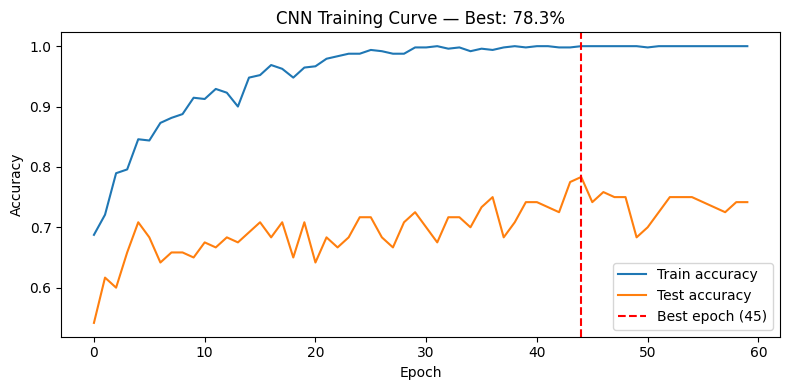

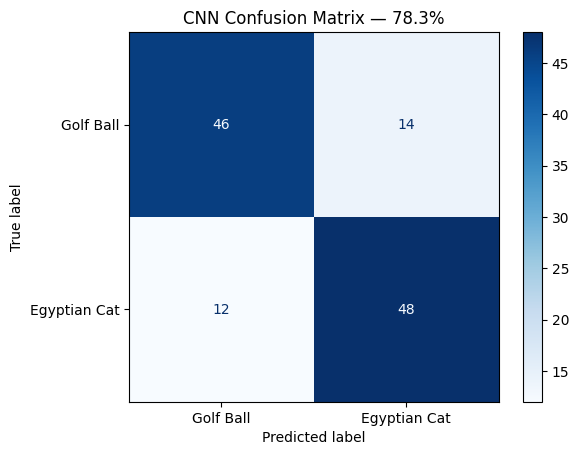


  Final Comparison:
    CNN accuracy: 78.3%


In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

x_train_cnn, x_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

x_train_t = torch.tensor(x_train_cnn, dtype=torch.float32)
x_test_t  = torch.tensor(x_test_cnn,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_cnn, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_cnn,  dtype=torch.float32)

train_dl = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=32, shuffle=True)

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = EEG_CNN(n_channels=n_channels, n_timepoints=n_timepoints).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_accs, test_accs = [], []
best_acc, best_epoch  = 0, 0

for epoch in range(60):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(model(xb).squeeze(), yb).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = (torch.sigmoid(model(x_train_t.to(device)).squeeze()) > 0.5).cpu().float()
        test_preds  = (torch.sigmoid(model(x_test_t.to(device)).squeeze())  > 0.5).cpu().float()
        train_acc   = (train_preds == y_train_t).float().mean().item()
        test_acc    = (test_preds  == y_test_t ).float().mean().item()

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc   = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_cnn_model.pt')

    print(f"Epoch {epoch + 1:2d} | Train: {train_acc:.3f} | Test: {test_acc:.3f}"
          f"{' ← best' if test_acc == best_acc else ''}")

print(f"\n  Best CNN accuracy: {best_acc:.3f} ({best_acc * 100:.1f}%) at epoch {best_epoch}")

model.load_state_dict(torch.load('best_cnn_model.pt'))
model.eval()
with torch.no_grad():
    test_preds = (torch.sigmoid(model(x_test_t.to(device)).squeeze()) > 0.5).cpu().float()
cnn_acc = (test_preds == y_test_t).float().mean().item()

plt.figure(figsize=(8, 4))
plt.plot(train_accs, label='Train accuracy')
plt.plot(test_accs,  label='Test accuracy')
plt.axvline(best_epoch - 1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title(f'CNN Training Curve — Best: {cnn_acc * 100:.1f}%')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test_cnn, test_preds.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=['Golf Ball', 'Egyptian Cat'])
disp.plot(cmap='Blues')
plt.title(f'CNN Confusion Matrix — {cnn_acc * 100:.1f}%')
plt.show()

print(f"\n  Final Comparison:")
print(f"    CNN accuracy: {cnn_acc * 100:.1f}%")

SVM model training and accuracy 

Extracting band power features...
Feature shape: (600, 105)
  Band Power SVM Accuracy: 0.867 (86.7%)


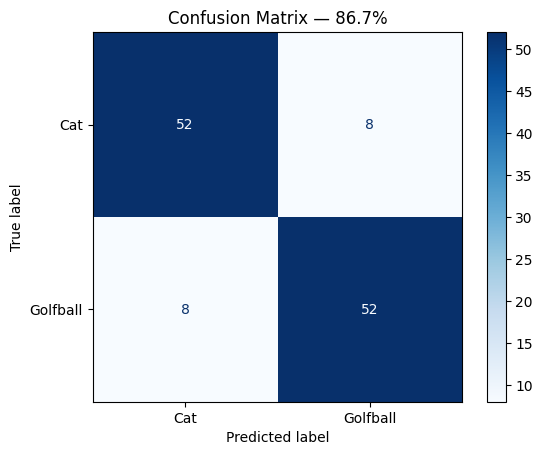

In [13]:
from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def extract_band_power(x, fs=1000):
    """Extract delta, theta, alpha, beta, gamma band power per channel"""
    bands = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 70)}
    features = []
    for trial in x:
        trial_feats = []
        for ch in trial:
            freqs, psd = welch(ch, fs=fs, nperseg=min(256, len(ch)))
            for lo, hi in bands.values():
                idx = (freqs >= lo) & (freqs <= hi)
                trial_feats.append(psd[idx].mean())
        features.append(trial_feats)
    return np.array(features)

print("Extracting band power features...")
x_feat = extract_band_power(x_data, fs=1000)
print(f"Feature shape: {x_feat.shape}")

x_train, x_test, y_train, y_test = train_test_split(
    x_feat, y_data, test_size=0.2, random_state=42, stratify=y_data
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(x_train_scaled, y_train)
y_pred = svm.predict(x_test_scaled)
acc_svm = accuracy_score(y_test, y_pred)
print(f"  Band Power SVM Accuracy: {acc_svm:.3f} ({acc_svm * 100:.1f}%)")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Cat', 'Golfball'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {acc_svm * 100:.1f}%')
plt.show()

SVM vs CNN Comparison Plot 

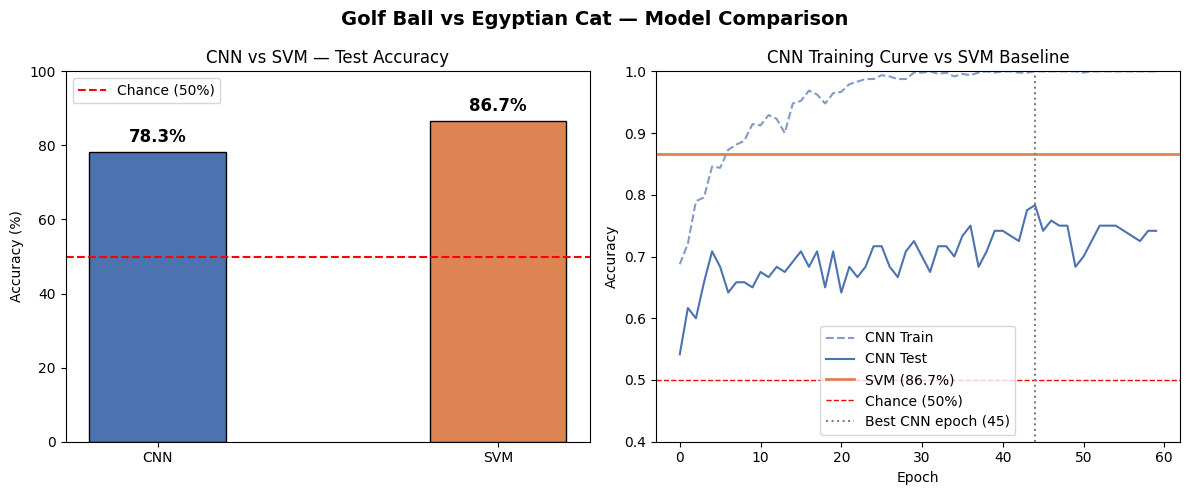


  Summary:
    CNN best accuracy: 78.3%
    SVM accuracy:      86.7%
    Chance baseline:   50.0%
    SVM advantage:     +8.3%


In [14]:
models_list = ['CNN', 'SVM']
accuracies  = [cnn_acc * 100, acc_svm * 100]
colors      = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(models_list, accuracies, color=colors, width=0.4, edgecolor='black')
axes[0].axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Chance (50%)')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('CNN vs SVM — Test Accuracy')
axes[0].legend()
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[1].plot(train_accs, label='CNN Train', color='#4C72B0', linestyle='--', alpha=0.7)
axes[1].plot(test_accs,  label='CNN Test',  color='#4C72B0')
axes[1].axhline(y=acc_svm, color='#DD8452', linestyle='-',  linewidth=2, label=f'SVM ({acc_svm * 100:.1f}%)')
axes[1].axhline(y=0.50,    color='red',     linestyle='--', linewidth=1, label='Chance (50%)')
axes[1].axvline(x=best_epoch - 1, color='gray', linestyle=':', label=f'Best CNN epoch ({best_epoch})')
axes[1].set_ylim(0.4, 1.0)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN Training Curve vs SVM Baseline')
axes[1].legend()

plt.suptitle('Golf Ball vs Egyptian Cat — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n  Summary:")
print(f"    CNN best accuracy: {cnn_acc * 100:.1f}%")
print(f"    SVM accuracy:      {acc_svm * 100:.1f}%")
print(f"    Chance baseline:   50.0%")
print(f"    SVM advantage:     +{acc_svm * 100 - cnn_acc * 100:.1f}%")